In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import utils.file as futils
import utils.data as datutils
import utils.plots as plots
import utils.corrs as corutils

import warnings
from pandas.errors import ParserWarning
import importlib

warnings.simplefilter(action='ignore', category=ParserWarning)
warnings.simplefilter(action='ignore', category=FutureWarning)

plt.rcParams['xtick.labelsize'] = 13
plt.rcParams['ytick.labelsize'] = 13
plt.rcParams['axes.labelsize'] = 18
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["mathtext.fontset"] = "cm"
plt.rcParams["font.family"] = "serif"

In [2]:
mah_dict = futils.get_mah_all()
dsdf = futils.get_ds(snap=125)

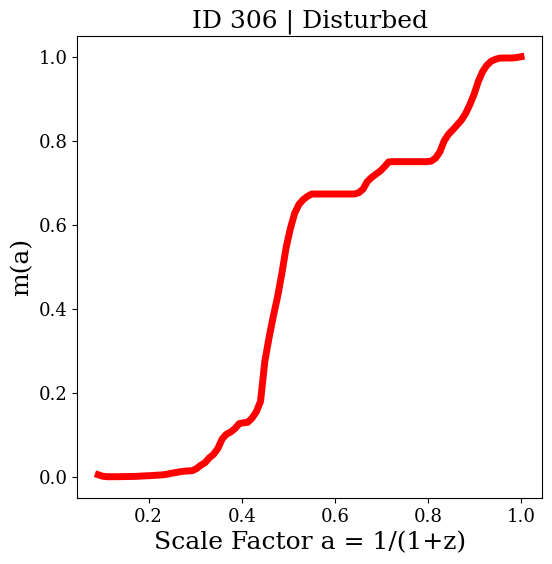

In [3]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
plots.plot_mah(indx=306, axs=axs, am=False)
plt.show()

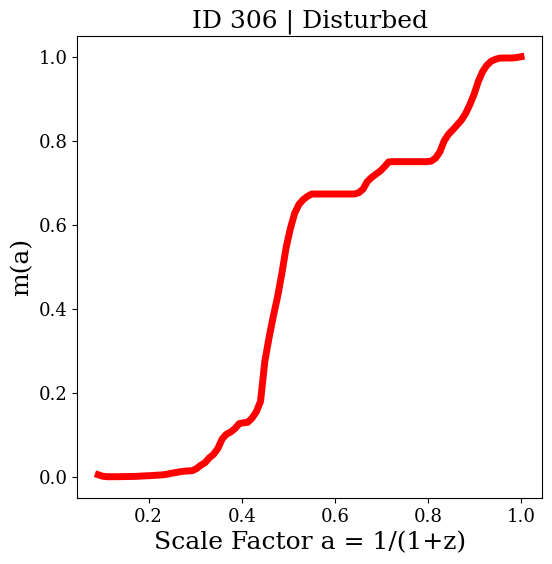

In [4]:
fig, axs = plt.subplots(nrows=1, ncols=1, figsize=(6, 6))
plots.plot_mah(indx=306, axs=axs, am=False)
plt.show()

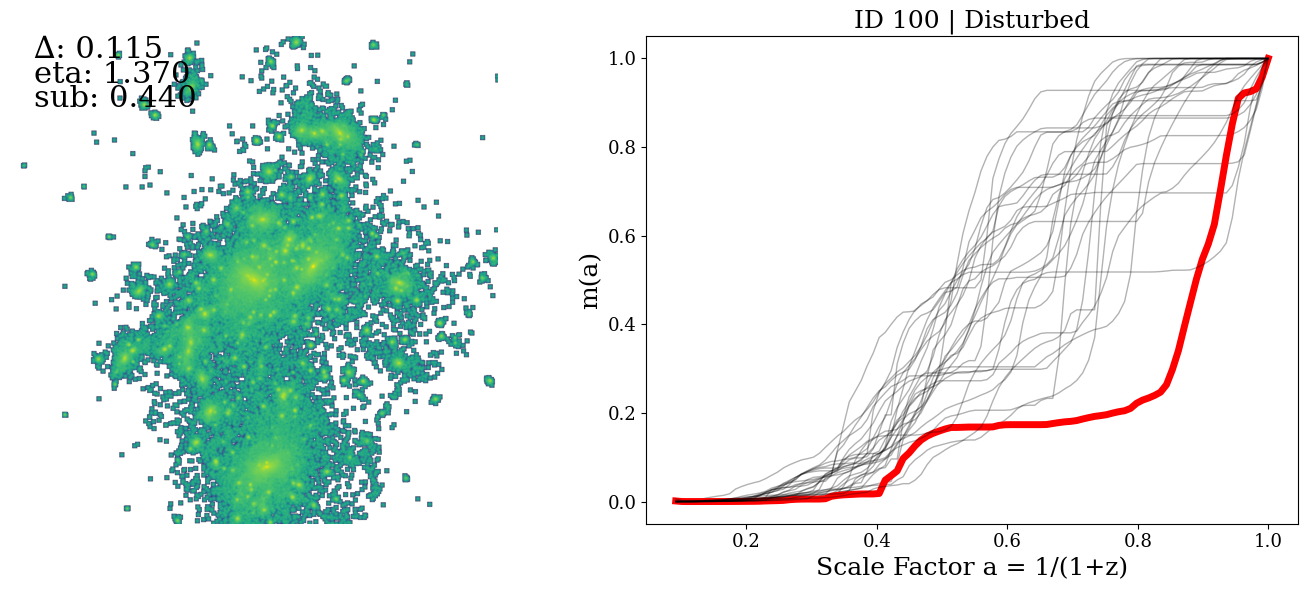

In [5]:
map_dir = 'data/gadgetx3k/maps/zx/'
indx = 100
file = f'bcg_{str(indx).zfill(4)}_125_2.fits'
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
mass_map = futils.load_map(file, map_dir)
plots.display_img(mass_map, axs[0])
axs[0].set_axis_off()
ecom = dsdf.loc[[indx]]['delta_200[4]'].values[0]
evir = dsdf.loc[[indx]]['eta_200[3]'].values[0]
esub = dsdf.loc[[indx]]['fm_200[5]'].values[0]
etxt = f'∆: {ecom:.3f}'
axs[0].annotate(etxt, xy=(0.05, 1.0),
                xycoords='axes fraction', fontsize=22, va='top')
etxt = f'eta: {evir:.3f}'
axs[0].annotate(etxt, xy=(0.05, 0.95),
                xycoords='axes fraction', fontsize=22, va='top')
etxt = f'sub: {esub:.3f}'
axs[0].annotate(etxt, xy=(0.05, 0.90),
                xycoords='axes fraction', fontsize=22, va='top')
plots.plot_mah(indx, axs=axs[1], show_relaxed=True)
plt.tight_layout()
# plt.savefig('plots/late_form.pdf', bbox_inches='tight')
plt.show()

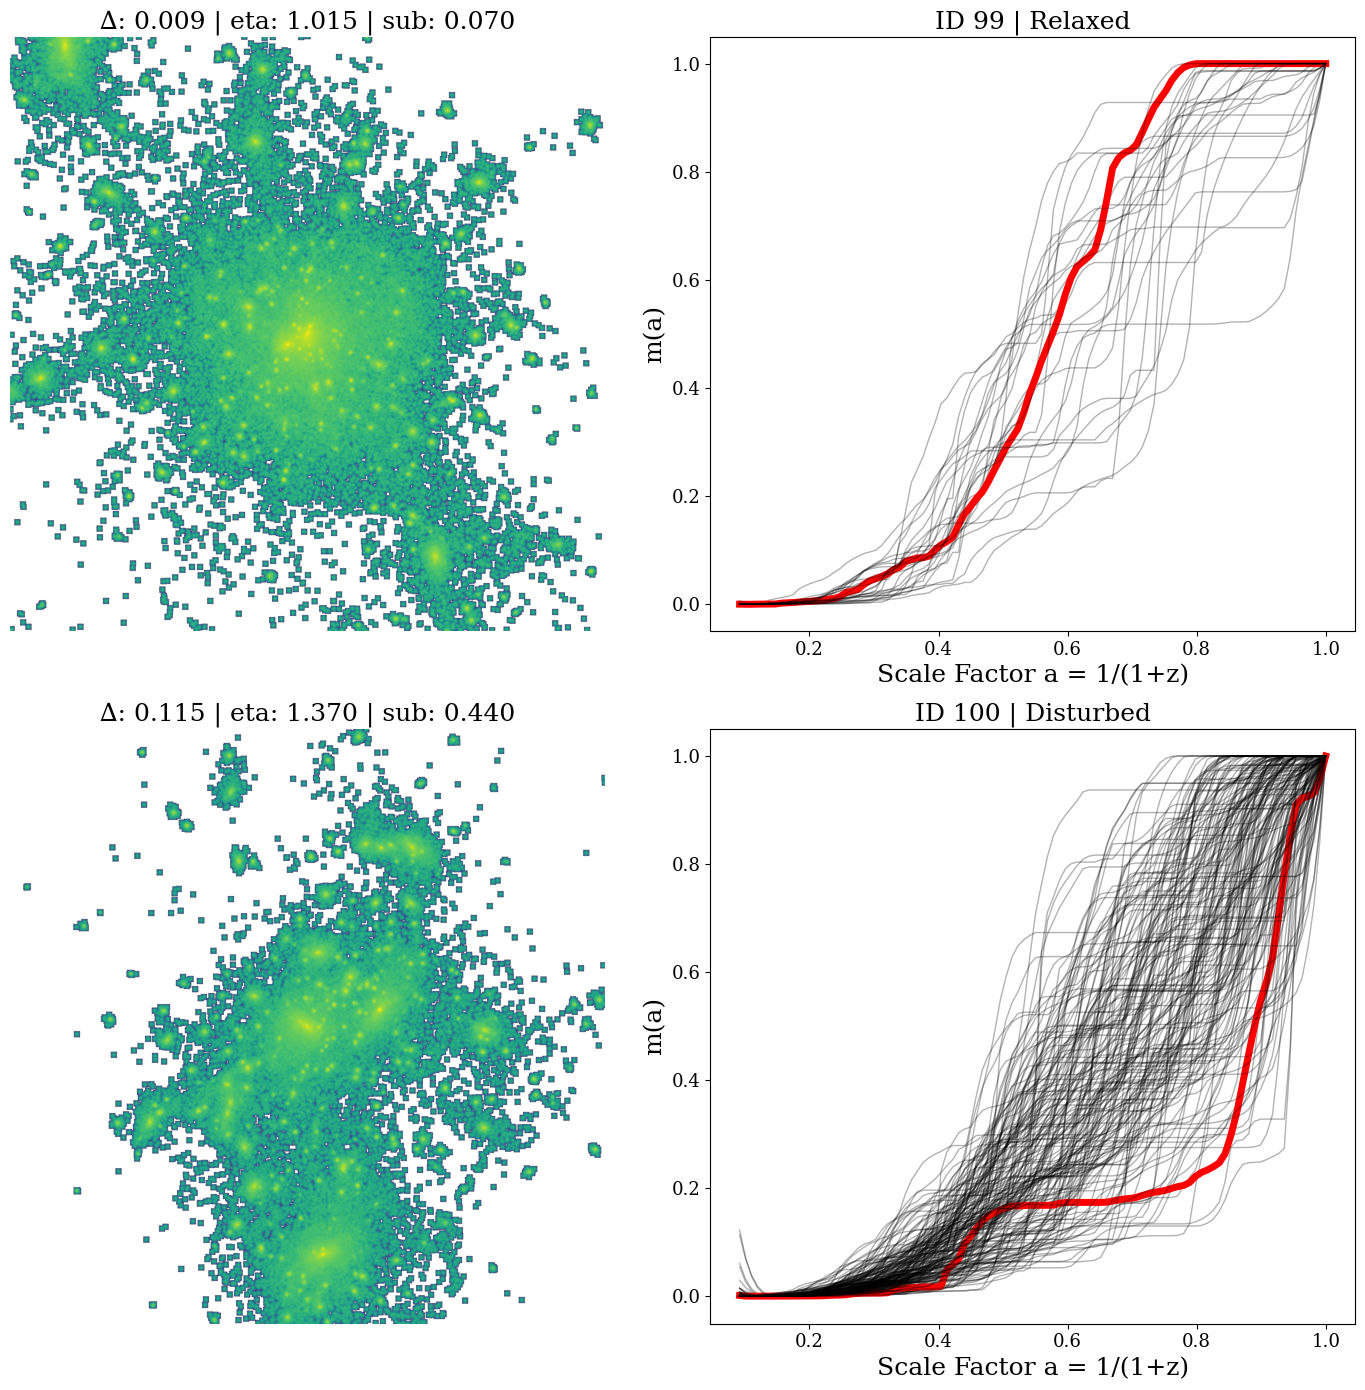

In [6]:
map_dir = 'data/gadgetx3k/maps/zx/'

indx = 99
file = f'bcg_{str(indx).zfill(4)}_125_2.fits'
fig, axs = plt.subplots(2, 2, figsize=(14, 14))
mass_map = futils.load_map(file, map_dir)
plots.display_img(mass_map, axs[0][0])
axs[0][0].set_axis_off()
ecom = dsdf.loc[[indx]]['delta_200[4]'].values[0]
evir = dsdf.loc[[indx]]['eta_200[3]'].values[0]
esub = dsdf.loc[[indx]]['fm_200[5]'].values[0]
axs[0][0].set_title(f'∆: {ecom:.3f} | eta: {evir:.3f} | sub: {esub:.3f}')
plots.plot_mah(indx, axs=axs[0][1], show_relaxed=True)

indx = 100
file = f'bcg_{str(indx).zfill(4)}_125_2.fits'
mass_map = futils.load_map(file, map_dir)
plots.display_img(mass_map, axs[1][0])
axs[1][0].set_axis_off()
ecom = dsdf.loc[[indx]]['delta_200[4]'].values[0]
evir = dsdf.loc[[indx]]['eta_200[3]'].values[0]
esub = dsdf.loc[[indx]]['fm_200[5]'].values[0]

axs[1][0].set_title(f'∆: {ecom:.3f} | eta: {evir:.3f} | sub: {esub:.3f}')
plots.plot_mah(indx, axs=axs[1][1], show_disturbed=True)

plt.tight_layout()
plt.savefig('plots/maps_mah.pdf')
plt.show()

# AHF Properties

In [7]:
ahf_file = 'data/gadgetx3k/AHFHaloHistory/NewMDCLUSTER_0001_halo_128000000000001.dat'
ahf = pd.read_csv(ahf_file, sep=r'\s+', index_col=False)
mah_dict = futils.get_mah_all()
ahf_df = datutils.ahf_zbin(0., ahf)

KeyError: 1

In [ ]:
ahf_dict, corrs_list, filtered_z_list = corutils.build_ma_corrs(
    mah_dict, ahf_df)
z_array = np.array(filtered_z_list)
aexp = 1/(1+z_array)